<a href="https://colab.research.google.com/github/jacquemainainsley/TransitMethodPhotonCount/blob/main/Photon_Count_New_(Photometry_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Background Information
*   Task: Make a universal code to find spectra for the number of photons emitted from an exoplanet at the feature wavelengths of certain biosignature gases by **querying data from the SIMBAD Photometry Viewer** and **using the blackbody radiation equation**.
*   Given Information
    *   Energy of a photon equation
        *   $E_{photon} = \frac{hc}{λ}$
        *   Units: $J$
    *   The scaling factor for the calculation
        *   $A \times t$
            *   $A$ = telescope collecting area ($cm^2$)
            *   $t$ = exposure time ($s$)
            *   Units: $cm^2 \times s$
        * Jansky to SI Units equation
            * $1 [Jy] = 10^{23} [\frac {erg}{s \times cm^2 \times Hz}]$
*   $B_{λ}$ can be obtained for each biosignature gas by averaging the wavelength range and finding the closest corresponding point. The spectral flux density, $B_{λ}$, can be converted from units $Jy$ to units $\frac {erg}{s \times cm^2 \times Hz}$.

*   Use $B_{λ}$, $E_{photon}$, and $A \times t$ to find $N$, the number of photons emitted from an exoplanet at an interval of wavelengths.
    *   $N = \int_{λ}^{λ} (\frac{B_{λ}}{λh} \times A \times t)dλ$
*   We will test this method using Proxima Centauri b as a reference exoplanet.
    *   We will also assume that $A =$ 7.0685 $\times 10^6 cm^2$ and $t =$ 100 $s$.
*   Each biosignature gas uses its own feature wavelength ($λ$) range. This is the interval of the integral.
    *   $O_2 =$ 1.25 - 1.28 $μm$
    *   $CO_2 =$ 4.17 - 4.51 $μm$
    *   $CH_4 =$ 3.41 - 3.71 $μm$
    *   $H_2O =$ 1.76 - 1.94 $μm$
*   From here, we are able to calculate the number of photons emitted for each biosignature gas at a feature wavelength range from an exoplanet. We can use this information, along with our calculated minimum photon count for a certain small error on our Poisson distribution, to decide how long to collect data for ($t$, exposure time) or how wide our detector should be ($A$, telescope collecting area) for a given exoplanet.

# Exoplanet Selection
*   We restricted the available exoplanets to those with the most appropriate conditions. In the search for exoplanets that are potentially habitable, we selected Earthlike candidates. We also selected exoplanets that are close and hosted by bright stars in order to maximize photon collection.
*   Conditions
    *   Observed by transit method
    *   Can sustain liquid water ($T_{eq} = [175 K, 647 K]$)
    *   Earthlike size $(R_{planet} =[0.7 R_E, 1.6 R_E]$)
    *   Close to observer ($d = [0 pc, 200 pc]$)
    *   Bright host star (KS-Band Magnitude = [0,8])
          * The KS-Band, an infrared band, is most appropriate for exoplanet observation.

*   Candidate Planets
    *   GJ 341 b
    *   HD 260655 b
    *   HD 260655 c
    *   GJ 357 b
    *   LTT 1445 A b
    *   L 98-59 b
    *   LHS 475 b
    *   Gliese 12 b
    *   GJ 3929 b
    *   TOI-244 b

*   Candidate Planet Extras
    *   LTT 1445 A c
    *   TOI-260 b
    *   L 98-59 c
    *   L 98-59 d
    *   HD 23472 f
    *   Kepler-409 b
    *   TOI 198 b
    *   Kepler-37 c
    *   LHS 1815 b

In [100]:
# Select a planet by typing it in.
planet = "LTT 1445 A c"

In [101]:
import numpy as np # import numpy package, which allows us to conduct mathematical operations for the defined quantities.
import astropy.units as u # import a Python package to call certain units.
import astropy.constants as const # import a Python package to call the value of certain constants.

In [102]:
# Define constants.
h = const.h # This is Planck's constant. (J/s)
c = const.c # This is the speed of light. (m/s)
k_B = const.k_B # This is Boltzmann's constant. (J/K)
pi = np.pi # This is pi.

Successfully retrieved 220 photometric data points for LTT 1445 A c.
<TableColumns names=('_RAJ2000','_DEJ2000','_tabname','_ID','_time','_etime','sed_freq','sed_flux','sed_eflux','sed_filter')>

--- SED Table ---
 sed_freq   sed_flux
   GHz         Jy   
---------- ---------
    541430     0.252
    745750     0.228
    541430     0.252
    563630    0.0854
    713280   0.00895
    138550       1.7
    181750      2.05
    241960      1.91
    138550       1.7
       ...       ...
    181750      2.05
    241960      1.91
    541430     0.221
    541430     0.128
    674900    0.0496
    2997.9   0.00229
    2997.9   0.00266
    4282.8   0.00451
    4282.8   0.00427
    445460     0.286
Length = 220 rows


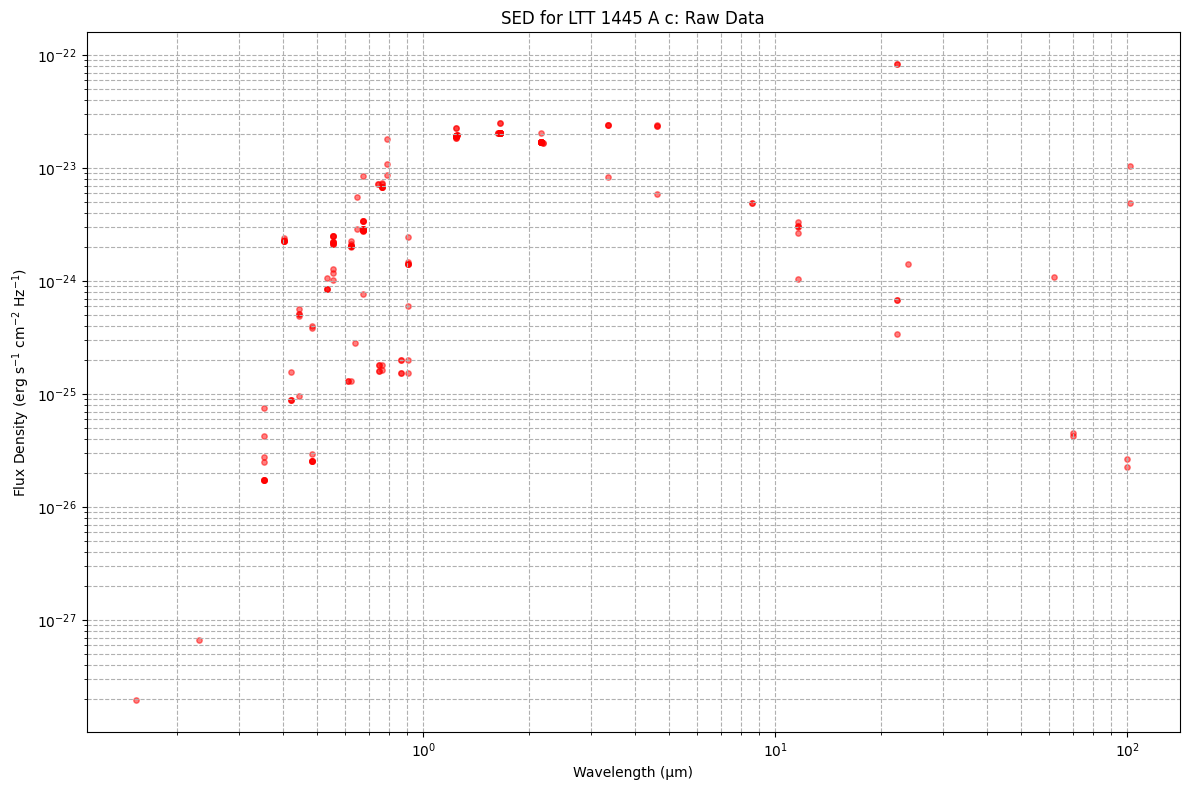

In [103]:
import urllib.parse # Import the parse package, which allows us to encode targets and special characters into a URL.
from astropy.table import Table # Import the table package, which allows us to read and generate VOTable data in the form of a table.
import matplotlib.pyplot as plt # Import the plotting package, which allows to generate plots of data.


# Before we can present raw photometry data, we must query it from VizieR SIMBAD.

radius_arcsec = 5 # Set a parameter, the search radius (as).
encoded_target = urllib.parse.quote(planet) # URL-encode the target (planet) name.

"""
Construct the URL for the VizieR SED service.
The -c parameter specifies the target object.
The -c.rs parameter specifies the search radius in arcseconds.
"""
url = f"https://vizier.cds.unistra.fr/viz-bin/sed?-c={encoded_target}&-c.rs={radius_arcsec}"

"""
Query the data given the chosen parameters.
Create a block, which will be useful given any errors.
Send a data query to the URL in order to read the data as an Astropy table.
"""
try:
    sed_table = Table.read(url, format="votable") # Read the data in an Astropy table.
    print(f"Successfully retrieved {len(sed_table)} photometric data points for {planet}.")
    print(sed_table.columns)
except Exception as e:
    print(f"An error occurred during the query: {e}")
    print("Please check the object name or internet connection.")
    sed_table = None # Set sed_table to None to avoid errors if the query is not successful.

wavelength = u.Quantity([], u.um) # Initialize wavelength to prevent errors if the query is not successful.
B_nu = u.Quantity([], u.erg / (u.s * u.cm**2 * u.Hz)) # Initialize B_nu to prevent errors if the query is not successful.


"""
If the raw data from SIMBAD VizierR exists, then we import a table containing the provided data.
We convert the necessary import data into the correct units. sed_freq, the frequency (GHz) becomes sed_freq, the frequency (Hz), which is then converted to wavelength (um).
                                                             sed_flux, the spectral flux density (Jy) becomes sed_flux, the spectral flux density (erg / (s * cm**2 * Hz)).
"""
if sed_table is not None and len(sed_table) > 0 and 'sed_freq' in sed_table.colnames and 'sed_flux' in sed_table.colnames:
    freq = sed_table["sed_freq"].quantity.to(u.Hz) # Import frequency with units.
    flux = sed_table["sed_flux"].quantity.to(u.Jy) # Import flux desnity with units

    wavelength = (c / freq).to(u.um) # Convert frequency to wavelength. Wavelength will be used as the most appropriate x-axis for a plot.
    B_nu = flux.to(u.erg / (u.s * u.cm**2 * u.Hz)) # Spectral flux density will be used as the most appropriate y-axis for a plot.


"""
If the raw data from SIMBAD VizierR exists, then we import a table containing sed_freq, the frequency (Hz)
                                                                              sed_flux, the spectral flux density (erg / (s * cm**2 * Hz)).
We obtain these values from sed_table after conversion to the proper units.
Unlike sed_table, sed_reduced only contains the data that we need for calculation.
Thus, we only need to print sed_reduced.
"""
if sed_table is not None:
    sed_reduced = Table()
    sed_reduced["sed_freq"] = sed_table["sed_freq"] # Define the first column of our table (frequency).
    sed_reduced["sed_flux"] = sed_table["sed_flux"] # Define the second column of our table (spectral flux density).

    print("\n--- SED Table ---")
    print(sed_reduced)

# Create a plot for the raw and filtered data.
plt.figure(figsize=(12, 8)) # Define the plot size.
plt.scatter(wavelength, B_nu, label="Raw Data", s=15, alpha=0.5, color='red') # Plot the data.
plt.xlabel('Wavelength (μm)') # Label the x-axis of the plot.
plt.ylabel('Flux Density (erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$)') # Label the y-axis of the plot.
plt.title(f'SED for {planet}: Raw Data') # Title the plot.
plt.xscale('log') # Scale the x-axis logarithmically.
plt.yscale('log') # Scale the y-axis logarithmically.
plt.grid(True, which="both", ls="--") # Create a grid for the plot.
plt.tight_layout() # Give the plot a clean and tight layout.
plt.show() # Show the plot.

Number of data points after Step 1 (dynamic flux percentile filtering, 35% removed): 143
Number of data points after Step 2 (unique wavelength filtering): 22
Final number of data points for interpolation: 22


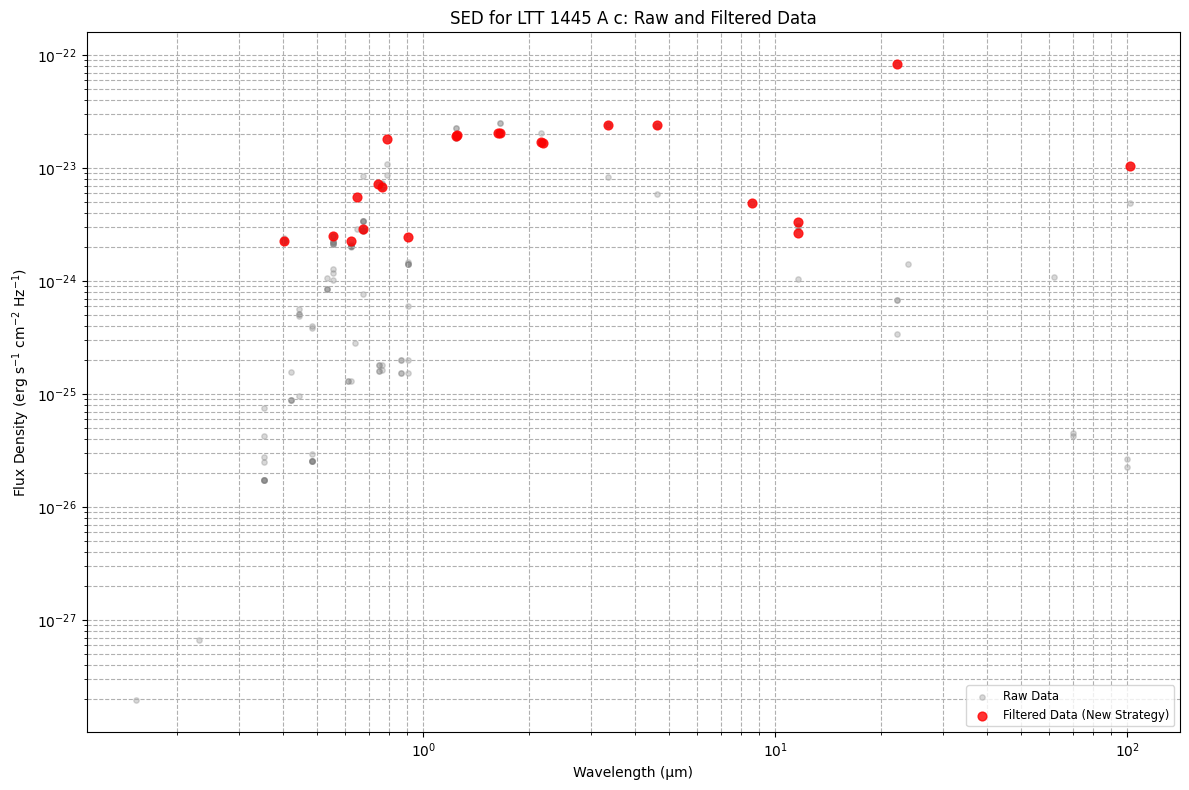

In [104]:
"""
We will perform a two-step filtering process in order to make the interpolated curve as accurate as possible.

1. Perform a dynamic filtering of spectral flux density values based on percentile.
   This can be adjusted, and will allow us to remove data clumps that interfere with the accuracy of the interpolated curve.
2. Filter out duplicate points for given wavelengths so that only unique wavelength-flux pairs and default data points contribute to the interpolated curve.

wavelength and B_nu will be considered the "raw" data.
"""

# Step 1: Dynamic flux density filtering based on percentile
# This removes the lowest flux density values that sometimes form a problematic clump.
# We apply this directly to the initial B_nu data.
flux_percentile_to_remove = 35 # Adjust this value to remove a percentage of the lowest flux densities. The input value corresponds to the percetage removed.

wavelength_filtered_step1 = wavelength # Perform the filtering process to the original data.
B_nu_filtered_step1 = B_nu # Perform the filtering process to the original data.

if len(B_nu) > 0:
    sorted_B_nu_for_percentile = np.sort(B_nu.value) # Extract and sort the numerical flux density values in ascending order. This will allow us to filter by percentile value.
    dynamic_flux_threshold = np.percentile(sorted_B_nu_for_percentile, flux_percentile_to_remove) * B_nu.unit # Calculate the dynamic threshold for spectral flux density, under which the spectral flux densities will be removed.
    mask_dynamic_flux = B_nu.value > dynamic_flux_threshold.value # Define which points are kept (those with spectral flux density values above the dynamic threshold).
    wavelength_filtered_step1 = wavelength[mask_dynamic_flux] # Filter the data. Define the wavelength values corresponding to filtered spectral flux density values.
    B_nu_filtered_step1 = B_nu[mask_dynamic_flux] # Filter the data. Define the filtered spectral flux density values.

print(f"Number of data points after Step 1 (dynamic flux percentile filtering, {flux_percentile_to_remove}% removed): {len(wavelength_filtered_step1)}")

# Step 2: Filtering out duplicate and non-default data points
# This ensures that for each wavelength, there is only one corresponding flux value, and the corresponding value is the best one.
# We apply this to the data filtered in Step 1 (dynamic flux density filtering).

# First, sort and store the data from Step 1.
sort_idx_step1 = np.argsort(wavelength_filtered_step1.value) # Sort data from Step 1 by wavelength. Data was already sorted by spectral flux density in the previous step.
wavelength_sorted_for_unique = wavelength_filtered_step1[sort_idx_step1] # Store the sorted wavelength values in variables.
B_nu_sorted_for_unique = B_nu_filtered_step1[sort_idx_step1] # Store the sorted spectral flux density values in variables.

# Then, identify and keep only unique and default wavelength-flux pairs.
unique_wavelength_values_step2, unique_indices_step2 = np.unique(wavelength_sorted_for_unique.value, return_index=True) # Find all unique wavelength values from the sorted list and only return default, or first, indices.
wavelength_final_filtered = wavelength_sorted_for_unique[unique_indices_step2] # Create wavelength arrays for the unique and default indices.
B_nu_final_filtered = B_nu_sorted_for_unique[unique_indices_step2] # Create spectral flux density arrays for the unique and default indices.

print(f"Number of data points after Step 2 (unique wavelength filtering): {len(wavelength_final_filtered)}")

print(f"Final number of data points for interpolation: {len(wavelength_final_filtered)}")

# Create a plot for the raw and filtered data.
plt.figure(figsize=(12, 8)) # Define the plot size.
plt.scatter(wavelength, B_nu, label="Raw Data", s=15, alpha=0.3, color='gray') # Plot the raw data.
plt.scatter(wavelength_final_filtered, B_nu_final_filtered, label="Filtered Data (New Strategy)", s=40, alpha=0.8, color='red', zorder=2) # Plot the filtered data.
plt.xlabel('Wavelength (μm)') # Label the x-axis of the plot.
plt.ylabel('Flux Density (erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$)') # Label the y-axis of the plot.
plt.title(f'SED for {planet}: Raw and Filtered Data') # Title the plot.
plt.xscale('log') # Scale the x-axis logarithmically.
plt.yscale('log') # Scale the y-axis logarithmically.
plt.legend(loc='lower right', fontsize='small') # Create a legend for the plot.
plt.grid(True, which="both", ls="--") # Create a grid for the plot.
plt.tight_layout() # Give the plot a clean and tight layout.
plt.show() # Show the plot.

In [105]:
# Define the feature wavelength ranges for all four biosignture gases. These will define the upper and lower limits of integration.
biosignature_gas_ranges = {"O2": (1.25 * u.um, 1.28 * u.um),
                           "CO2": (4.17 * u.um, 4.51 * u.um),
                           "CH4": (3.41 * u.um, 3.71 * u.um),
                           "H2O": (1.76 * u.um, 1.94 * u.um)}

# Choose colors for the feature wavelength ranges for all four biosignature gases.
colors = {'O2': 'green',
          'CO2': 'blue',
          'CH4': 'purple',
          'H2O': 'orange'}

# Define a function for average wavelength.
def avg_wavelength(lambda_min, lambda_max):
    return 0.5 * (lambda_min + lambda_max)

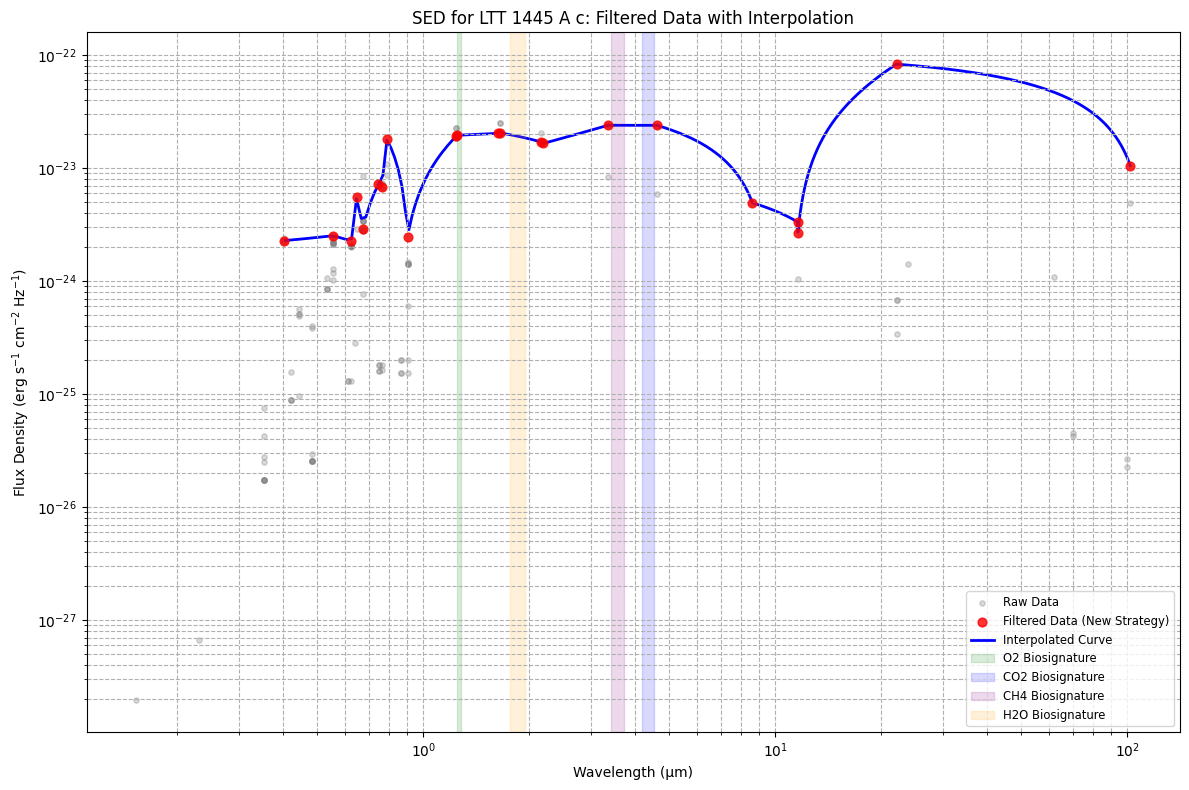

In [106]:
from scipy.interpolate import interp1d # Import the interp1d package in order to create an interpolated curve for the queried and filtered data.

# Define interp_func, the interpolation function.
interp_func = interp1d(wavelength_final_filtered.value, #The interpolation function is a function of the filtered wavelength.
                       B_nu_final_filtered.value, # The interpolation function is a function of the filtered spectral flux density.
                       kind='linear', # The interpolation function is linear.
                       bounds_error=False, # The interpolation will allow for calculated values outside of the original data range.
                       fill_value="extrapolate") # The interpolation function may guess values outside of the original data range.

# Create a helper function for the interpolation strategy in order to generate a plot.
def plot_interpolation_strategy_new(filtered_wavelength, filtered_B_nu, title, raw_wavelength, raw_B_nu, biosignature_gas_ranges, colors, interp_function_for_plot):
    # Ensure that there is enough data to successfully perform an interpolation.
    if len(filtered_wavelength) < 2:
        print(f"Warning: Not enough data points ({len(filtered_wavelength)}) for interpolation after filtering: {title}. Skipping plot.")
        return
    # Ensure that the wavelength range is smooth and covers the data.
    unique_wav_values, unique_idx = np.unique(filtered_wavelength.value, return_index=True)
    if len(unique_wav_values) < 2:
        print(f"Warning: Not enough *unique* data points ({len(unique_wav_values)}) for interpolation after filtering: {title}. Skipping plot.")
        return
    sorted_filtered_wavelength = filtered_wavelength[unique_idx] # Use the filtered and sorted wavelength data.
    sorted_filtered_B_nu = filtered_B_nu[unique_idx] # Use the filtered and sorted spectral flux density data.

    lambda_smooth = np.linspace(sorted_filtered_wavelength.min().value, sorted_filtered_wavelength.max().value, 5000) # Generate a range of smooth wavelengths.
    B_nu_smooth = interp_function_for_plot(lambda_smooth) # Use the interpolation function to calculate corresponding smooth spectral flux density values.

    # Create a plot for the filtered data and its interpolated curve.
    plt.figure(figsize=(12, 8)) # Define the plot size.
    plt.scatter(raw_wavelength, raw_B_nu, label="Raw Data", s=15, alpha=0.3, color='gray') # Plot the raw data.
    plt.scatter(sorted_filtered_wavelength, sorted_filtered_B_nu, label="Filtered Data (New Strategy)", s=40, alpha=0.8, color='red', zorder=2) # Plot the filtered data.
    plt.plot(lambda_smooth, B_nu_smooth, label="Interpolated Curve", linewidth=2, color='blue', zorder=1) # Plot the interpolated curve as a line plot.
    # Overlay the biosignature gas ranges.
    for gas, (lambda_min, lambda_max) in biosignature_gas_ranges.items():
        plt.axvspan(lambda_min.to(u.um).value, lambda_max.to(u.um).value, color=colors[gas], alpha=0.15, label=f'{gas} Biosignature')
    plt.xlabel('Wavelength (μm)') # Label the x-axis of the plot.
    plt.ylabel('Flux Density (erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$)') # Label the y-axis of the plot.
    plt.title(f'SED for {planet}: Filtered Data with Interpolation') # Title the plot.
    plt.legend(loc='lower right', fontsize='small') # Create a legend for the plot.
    plt.xscale('log') # Scale the x-axis logarithmically.
    plt.yscale('log') # Scale the y-axis logarithmically.
    plt.grid(True, which="both", ls="--") # Create a grid for the plot.
    plt.tight_layout() # Give the plot a clean and tight layout.
    plt.show() # Show the plot.

# Call upon the helper function for the interpolation strategy in order to generate the plot.
plot_interpolation_strategy_new(wavelength_final_filtered, B_nu_final_filtered, f'SED for {planet}: Filtered Data with Interpolation',
                                wavelength, B_nu, biosignature_gas_ranges, colors, interp_func)

In [107]:
# Initialize a dictionary for the interpolated spectral flux density values for each biosignature gas.
B_nu_interp_values = {}

# Use a for ... in statement in order to iterate through each biosignature gas and its respective wavelength range.
for gas, (lambda_min, lambda_max) in biosignature_gas_ranges.items():

    # Call upon the average wavelength function (avg_wavelength) in order to calculate the average wavelengths for each biosignature gas for a selected exoplanet.
    lambda_avg = avg_wavelength(lambda_min, lambda_max)

    #The flux density for each biosignature gas will be sampled from its average wavelength value.
    # Call upon the interpolated curve function (interp_func) in order to find the interpolated flux density at each average wavelength value.
    flux_interp_value = interp_func(lambda_avg.to(u.um).value)
    flux_interp = flux_interp_value * (u.erg / (u.s * u.cm**2 * u.Hz)) # Apply the proper units of spectral flux density in terms of wavelength.

    # Store the interpolated spectral flux density values for each biosignature gas in the dictionary.
    B_nu_interp_values[gas] = flux_interp

    print(gas, lambda_min, lambda_max)
    print(f"{gas}: interpolated flux = {flux_interp}")

O2 1.25 um 1.28 um
O2: interpolated flux = 1.953153679622871e-23 erg / (Hz s cm2)
CO2 4.17 um 4.51 um
CO2: interpolated flux = 2.3900000516345212e-23 erg / (Hz s cm2)
CH4 3.41 um 3.71 um
CH4: interpolated flux = 2.3900000516345212e-23 erg / (Hz s cm2)
H2O 1.76 um 1.94 um
H2O: interpolated flux = 1.9135389214245263e-23 erg / (Hz s cm2)


In [108]:
# Define the parameters.
"""
Use the astropy irreducible standard units. (Our exception is length, for which we will use an SI prefix in order to fit the CGS system for blackbody radiation equation.)
Length (Distance) has units of centimeters (cm).
Time has units of seconds (s).
Spectral Flux Density has units of Jansky, or (10^23 erg/(s*cm^2*Hz)).
"""
A = pi * (15 * u.m).to(u.cm)**2 # Represent the telescope area in centimeters squared (cm²).
t = 100 * u.s # Represent the exposure time in seconds (s).

print(f"Area: {A}")
print(f"Time: {t}")

Area: 7068583.470577034 cm2
Time: 100.0 s


In [109]:
# Define a function for spectral radiance.
def photon_radiance(lambda_, B_nu_value, A, t):
    # Photon radiance is a function of wavelength, photon flux (in terms of frequency), area, and time.
    """
    This function calculates the spectral radiance of a star.
    Input:
    lambda_, the wavelength of the electromagnetic radiation (m).
    B_nu_value, the spectral flux density of the electromagnetic radiation in terms of frequency (erg / (s * cm**2 * m))
          B_nu_value is multiplied by c, the speed of light (m / s)
                        divided by lambda_, the wavelength (m), squared
          resulting in B_nu, the spectral flux density of the electromagnetic radiation in terms of wavelength. (erg / (s * cm**2 * Hz))
    A, the telescope collecting area (m**2).
    t, the exposure time (s).
    Output:
    spectral_radiance, the spectral radiance. (W / (m**2 * Hz * sr))
    """
    B_lambda = B_nu_value * (c / lambda_**2) # Convert spectral flux density from frequency-based measurements to wavelength-based measurements.

    photon_flux = (B_lambda / (h * c / lambda_)) # Define the equation for spectral radiance.
    scaling_factor = (A * t) # Define the equation of the scaling factor.

    return photon_flux * scaling_factor

# What do we know about numpy.trapezoid?

*   The Trapezoidal Rule is a method of approximating integration by splitting an area we wish to integrate into trapezoids and summing the areas of each trapezoid.
*  As $n$ increases, $\Delta x$ gets progressively smaller and we sum more and more trapezoids, and the approximation of the integral becomes more accurate.
      *   I use high values of n because it makes the integral more accurate.
*   While numpy.trapezoid is array-based, we are integrating along a parametric curve. To do so, we must define x and y where x is in np.linspace (an array of evenly-spaced points). We must also define $n$, which tells us how precise our approximation is.

In [110]:
# Define a function for photon count.
def photon_count_method2(gas_name, lambda_min, lambda_max, A, t, B_lambda_values, n_points=1000): # Elements have feature wavelengths. The range is used for the bound of the integral.
    B_nu_for_gas = B_lambda_values[gas_name] # Retrieve the specific B_nu_value for this gas.
    x = np.linspace(lambda_min, lambda_max, num=n_points) # Define the x variable. Consider integration to be done along the x-y scale.
    y = photon_radiance(x, B_nu_for_gas, A, t) # Define the y variable. Consider integration to be done along the x-y scale.
    photon_count = np.trapezoid(y, x) # Define photon count as the calculated integral.

    return photon_count

In [111]:
# Use a for ... in statement in order to iterate through each biosignature gas and its respective wavelength range.
for gas, (lambda_min, lambda_max) in biosignature_gas_ranges.items():

    # Call upon the photon count function (photon_count_method_2) in order to calculate the photon counts for each biosignature gas for a selected exoplanet.
    photon_count = photon_count_method2(gas, lambda_min, lambda_max, A, t, B_nu_interp_values)

    print(f"Photon count for {gas} on {planet}: {(photon_count).decompose()}")

Photon count for O2 on LTT 1445 A c: 49415576082.34546
Photon count for CO2 on LTT 1445 A c: 199841520007.9196
Photon count for CH4 on LTT 1445 A c: 214982314541.09225
Photon count for H2O on LTT 1445 A c: 198773005525.94122
